In [ ]:
# Install the required libraries for LangChain, LangGraph, and PDF retrieval.
! pip install langchain langchain-openai langchain-community langgraph python-dotenv faiss-cpu pypdf


  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
Using cached requests-2.34.2-py3-none-any.whl (73 kB)

  Attempting uninstall: requests

    Found existing installation: requests 2.32.3

   ---------------------------------------- 0/2 [requests]
    Uninstalling requests-2.32.3:
   ---------------------------------------- 0/2 [requests]
   ---------------------------------------- 0/2 [requests]
      Successfully uninstalled requests-2.32.3
   ---------------------------------------- 0/2 [requests]
   ---------------------------------------- 0/2 [requests]
   ---------------------------------------- 0/2 [requests]
   ---------------------------------------- 0/2 [requests]
   ---------------------------------------- 0/2 [requests]
   ---------------------------------------- 0/2 [requests]
   ---------------------------------------- 0/2 [requests]
   ---------------------------------------- 0/2 [requests]
   -------------------- ------------------- 1/2 [langchain]
   --

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
spyder 6.0.7 requires bcrypt>=4.3.0, but you have bcrypt 3.2.0 which is incompatible.
spyder 6.0.7 requires ipython!=8.17.1,<9.0.0,>=8.13.0; python_version > "3.8", but you have ipython 9.4.0 which is incompatible.


In [ ]:
# Install the specialized text splitter package needed for LangChain.
pip install langchain-text-splitters

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Import the OpenAI model, embeddings, PDF loading, text splitting, vector store,
# and LangGraph tools needed for the RAG example.
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
# from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition

In [5]:
# Load environment variables such as API keys from the .env file.
load_dotenv()

True

In [6]:
# Create the chat LLM used for answering questions and orchestrating tool calls.
llm = ChatOpenAI(model='gpt-4o-mini')

In [7]:
# Load the PDF file and parse it into LangChain Document objects.
loader = PyPDFLoader("intro-to-ml.pdf")
docs = loader.load()

In [8]:
# Check how many Document objects were loaded from the PDF.
len(docs)

392

In [9]:
# Split the document text into overlapping chunks for more accurate retrieval.
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [10]:
# Confirm the number of text chunks created from the PDF.
len(chunks)

973

In [11]:
# Create embeddings for chunks and build a FAISS vector store for retrieval.
embeddings = OpenAIEmbeddings(model='text-embedding-3-small')
vector_store = FAISS.from_documents(chunks, embeddings)

In [ ]:
# Display the vector store object to confirm it was created successfully.
vector_store

In [ ]:
# Create a retriever that returns the top 4 most similar chunks for a query.
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [14]:
@tool
def rag_tool(query):

    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """
    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        'query': query,
        'context': context,
        'metadata': metadata
    }

In [ ]:
# Bind the retrieval tool to the language model so it can call the tool during chat.
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [ ]:
# Define the chat state for the LangGraph graph, including message history.
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [ ]:
# Define the graph node that sends the current messages to the tool-enabled LLM.
def chat_node(state: ChatState):

    messages = state['messages']

    response = llm_with_tools.invoke(messages)

    return {'messages': [response]}

In [ ]:
# Wrap the retrieval tool in a LangGraph tool node for graph execution.
tool_node = ToolNode(tools)

In [ ]:
# Build the LangGraph state graph and compile it into the final chatbot.
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot = graph.compile()

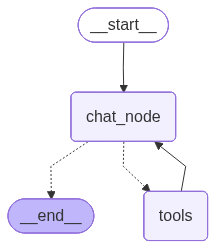

In [ ]:
# Display the compiled chatbot object to verify the graph was created.
chatbot

In [ ]:
# Run the chatbot on a sample question using PDF-based retrieval context.
result = chatbot.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "Using the pdf notes, explain how to find the ideal value of K in KNN"
                )
            )
        ]
    }
)

In [ ]:
# Print the final chatbot response from the invocation.
print(result['messages'][-1].content)

To find the ideal value of K in the k-Nearest Neighbors (k-NN) algorithm, consider the following points:

1. **Choosing K**: The "K" in k-NN represents the number of nearest neighbors considered when making a prediction. Instead of taking into account only the closest neighbor, the algorithm can factor in multiple neighbors. This introduces a voting mechanism where the most frequent class among the K neighbors is chosen as the output.

2. **Impact of K on Performance**:
   - A small value of K (like K=1) can lead to a model that is sensitive to noise and may overfit the training data.
   - A larger K can smooth out predictions but may lead to underfitting if K is too large, making the model less sensitive to the structure of the data.

3. **Hyperparameter Tuning**: The ideal value of K is often determined using cross-validation. You would typically evaluate the model's performance by trying different values of K and selecting the one that yields the best results in terms of accuracy or

In [ ]:
# End of notebook cell list.